## Acknowledgement of GenAI Use

# Part 1: Data Collection
Open the dataset and check the current values 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import sklearn

pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
df = pd.read_excel("sydney_housing.xlsx", sheet_name="data")
df["type_group"] = np.where(df["property_type"] == "Apartment/Unit", "Apartment", "House & other")
print(df.shape)
df.head()

(120, 12)


,address,price,suburb,sold_date,property_type,bedrooms,bathrooms,parking,land_size,description,flag,type_group
0,"28 Duckmallois Avenue, Blacktown NSW 2148",1225000,Blacktown,2026-06-15,House,3,1,2,834.70,"SOUTH BLACKTOWN OPPORTUNITY ON 834.7SQM LAND, ...",NaN,House & other
1,"32 Kurrajong Crescent, Blacktown NSW 2148",1015000,Blacktown,2026-04-17,House,3,1,2,582.00,First Time to Market in 62 Years Renovate or R...,NaN,House & other
2,"3 Flyer Glade, Blacktown NSW 2148",890000,Blacktown,2026-04-09,House,2,2,1,192.00,Premium Lifestyle Opportunity in FAIRWATER\nSu...,NaN,House & other
3,"6 Chippers Glade, Blacktown NSW 2148",904000,Blacktown,2026-03-06,Semi-detached,2,2,1,155.00,"RARE 2 BEDROOM, 2.5 BATHROOM, SEMI-DETACHED HO...",NaN,House & other
4,"14 Cut Glade, Blacktown NSW 2148",866000,Blacktown,2026-03-20,House,2,1,1,164.50,FAIRWATER. Modern House\nSurrounded by natural...,NaN,House & other


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   address        120 non-null    object        
 1   price          120 non-null    int64         
 2   suburb         120 non-null    object        
 3   sold_date      120 non-null    datetime64[ns]
 4   property_type  120 non-null    object        
 5   bedrooms       120 non-null    int64         
 6   bathrooms      120 non-null    int64         
 7   parking        120 non-null    int64         
 8   land_size      47 non-null     float64       
 9   description    118 non-null    object        
 10  flag           3 non-null      object        
 11  type_group     120 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(6)
memory usage: 11.4+ KB


In [4]:
df.describe()

,price,sold_date,bedrooms,bathrooms,parking,land_size
count,120.00,120,120.00,120.00,120.00,47.00
mean,"1,335,812.57",2026-03-24 02:48:00,2.77,1.86,1.65,529.92
min,"320,000.00",2023-04-05 00:00:00,1.00,1.00,0.00,130.00
25%,"627,500.00",2026-03-16 12:00:00,2.00,1.00,1.00,216.50
50%,"864,500.00",2026-08-19 12:00:00,2.00,2.00,1.00,556.00
75%,"1,233,750.00",2026-09-03 00:00:00,3.00,2.00,2.00,739.80
max,"11,500,000.00",2026-09-18 00:00:00,7.00,5.00,6.00,"1,730.00"
std,"1,650,737.05",NaN,1.28,0.94,1.21,341.28


# Part 2: Data Understanding and Feature Engineering

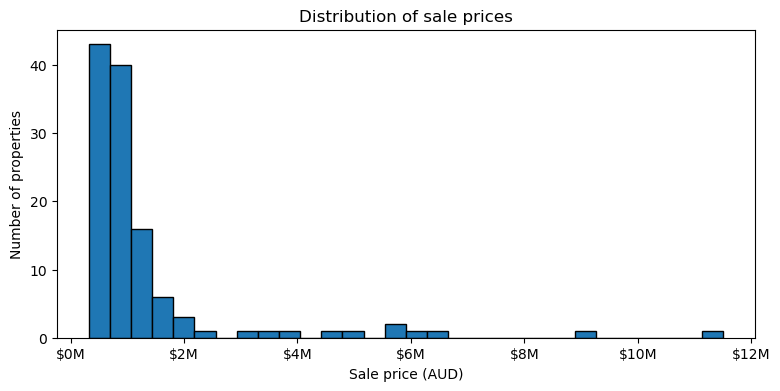

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.hist(df["price"], bins=30, edgecolor="black")
plt.xlabel("Sale price (AUD)")
plt.ylabel("Number of properties")
plt.title("Distribution of sale prices")
from matplotlib.ticker import FuncFormatter
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))
plt.show()

In [6]:
df.nlargest(2, "price")

,address,price,suburb,sold_date,property_type,bedrooms,bathrooms,parking,land_size,description,flag,type_group
85,"8-10 Llandilo Avenue, Strathfield NSW 2135",11500000,Strathfield,2026-08-13,House,6,5,6,"1,730.00","Grand Residence on 1,730sqm level block with E...",NaN,House & other
84,"3 Augusta Street, Strathfield NSW 2135",9150000,Strathfield,2026-08-15,House,5,4,6,"1,016.00",Epitome of resort luxury backing onto Strathfi...,NaN,House & other


In [7]:
# Count the number of properties priced ≤ $1.4M
n = (df["price"] <= 1_400_000).sum()
print(n, f"{n / len(df):.0%}")

# View the 5 most expensive properties
df.nlargest(5, "price")[["address", "suburb", "property_type", "land_size", "price"]]

99 82%


,address,suburb,property_type,land_size,price
85,"8-10 Llandilo Avenue, Strathfield NSW 2135",Strathfield,House,"1,730.00",11500000
84,"3 Augusta Street, Strathfield NSW 2135",Strathfield,House,"1,016.00",9150000
73,"13 Augusta Street, Strathfield NSW 2135",Strathfield,House,"1,012.00",6350000
100,"88 Albyn Road, Strathfield NSW 2135",Strathfield,House,"1,018.00",6210000
95,"9 Birnam Grove, Strathfield NSW 2135",Strathfield,House,784.10,5580000


## Price distribution

The distribution of sale prices is strongly right-skewed. 99 of the 120 properties (82%) sold for AUD 1.4M or less, with the middle 50% between AUD 627,500 and AUD 1,233,750. The mean (AUD 1.34M) is well above the median (AUD 864,500) because a few very expensive properties pull it upward, so the median is a better measure of a typical price.

The two largest outliers, 8-10 Llandilo Avenue (AUD 11.5M) and 3 Augusta Street (AUD 9.15M), appear to be genuine sales rather than data errors. Both are houses with 5–6 bedrooms on land of over 1,000 m², and their listing descriptions indicate luxury homes, so they were kept in the dataset. In fact, all five most expensive properties are houses in Strathfield with large land sizes (784–1,730 m²), which suggests that suburb and land size may be strong drivers of price.

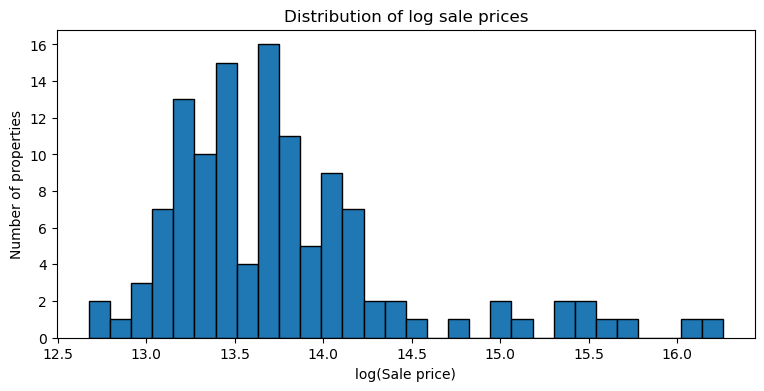

In [8]:
import numpy as np

plt.figure(figsize=(9, 4))
plt.hist(np.log(df["price"]), bins=30, edgecolor="black")
plt.xlabel("log(Sale price)")
plt.ylabel("Number of properties")
plt.title("Distribution of log sale prices")
plt.show()

In [9]:
df[np.log(df["price"]) > 14.6][["suburb", "type_group"]].value_counts()

suburb       type_group   
Strathfield  House & other    12
Name: count, dtype: int64

In [10]:
print("Skewness of price:", round(df["price"].skew(), 2))
print("Skewness of log(price):", round(np.log(df["price"]).skew(), 2))

Skewness of price: 3.81
Skewness of log(price): 1.55


## Log-transformed price

Compared with the original histogram, log(price) spreads the main body of properties (roughly AUD 440,000 – 1.6M) into a much more symmetric, bell-like shape, so the extreme values no longer dominate the scale. However, the log transformation reduces the skew without fully removing it: skewness falls from 3.81 to 1.55, which is still above 1. The remaining right tail is a small, separate group of 12 properties above roughly AUD 2.4M. All 12 are Strathfield houses (12 of the 13 in the dataset), which suggests that suburb and property type will be needed to explain the remaining skew. This motivates modelling log(price) in Part 3, with suburb and property type as key features.

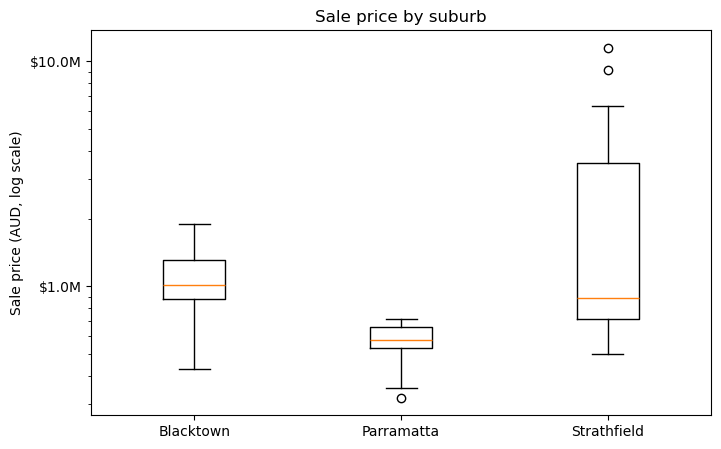

In [11]:
suburbs = ["Blacktown", "Parramatta", "Strathfield"]
data = [df.loc[df["suburb"] == s, "price"] for s in suburbs]

plt.figure(figsize=(8, 5))
plt.boxplot(data)
plt.xticks([1, 2, 3], suburbs)
plt.yscale("log")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"${y/1e6:.1f}M"))
plt.ylabel("Sale price (AUD, log scale)")
plt.title("Sale price by suburb")
plt.show()

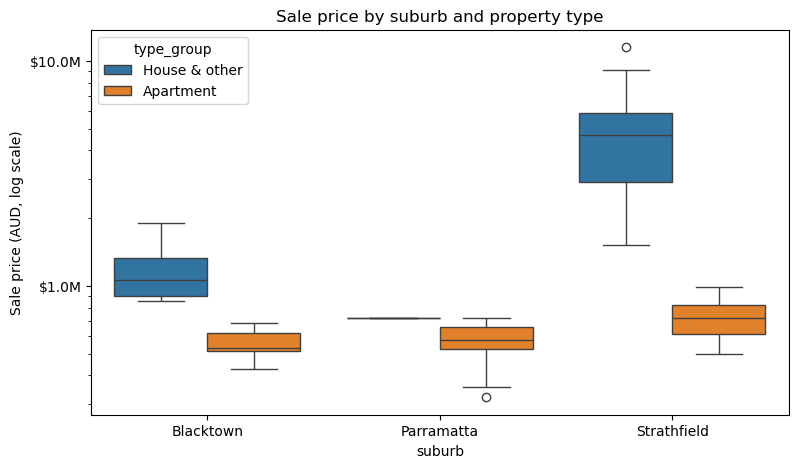

In [12]:
import seaborn as sns

df["type_group"] = np.where(df["property_type"] == "Apartment/Unit", "Apartment", "House & other")

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="suburb", y="price", hue="type_group", order=suburbs)
plt.yscale("log")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"${y/1e6:.1f}M"))
plt.ylabel("Sale price (AUD, log scale)")
plt.title("Sale price by suburb and property type")
plt.show()

In [13]:
df.groupby(["suburb", "type_group"])["price"].agg(["count", "median"])

count       median
suburb      type_group                       
Blacktown   Apartment          5   527,000.00
            House & other     45 1,062,500.00
Parramatta  Apartment         34   577,500.00
            House & other      1   720,000.00
Strathfield Apartment         20   721,000.00
            House & other     15 4,695,000.00

In [14]:
display(df.groupby("suburb")["price"].median())
pd.crosstab(df["suburb"], df["property_type"])

suburb
Blacktown     1,010,000.00
Parramatta      580,000.00
Strathfield     885,000.00
Name: price, dtype: float64

property_type,Apartment/Unit,House,Semi-detached,Terrace,Townhouse
suburb,,,,,
Blacktown,5,35,6,3,1
Parramatta,34,0,0,0,1
Strathfield,20,13,0,0,2


## Differences between suburbs

When all property types are combined, Blacktown's median price (AUD 1,010,000) is higher than Strathfield's (AUD 885,000). Comparing within the same property type reverses this conclusion. Strathfield is the most expensive suburb for both apartments (median AUD 721,000) and houses and other non-apartment dwellings (median AUD 4,695,000, about 4.4× Blacktown's AUD 1,062,500).

Strathfield's overall median appeared lower only because of its property mix: 57% of its sales were apartments, compared with just 10% in Blacktown. This is an example of **Simpson's paradox**.

The suburb effect is also not constant. Strathfield is about 1.4× more expensive than Blacktown for apartments, but about 4.4× for houses, which suggests an **interaction** between suburb and property type.

*Notes:*
- The "House & other" group includes all non-apartment dwellings. For example, Strathfield's group contains 13 houses and 2 townhouses.
- Some groups are too small to draw conclusions from. Parramatta has no house sales and only one townhouse (4/44-50 Thomas St), and Blacktown has only five apartment sales.

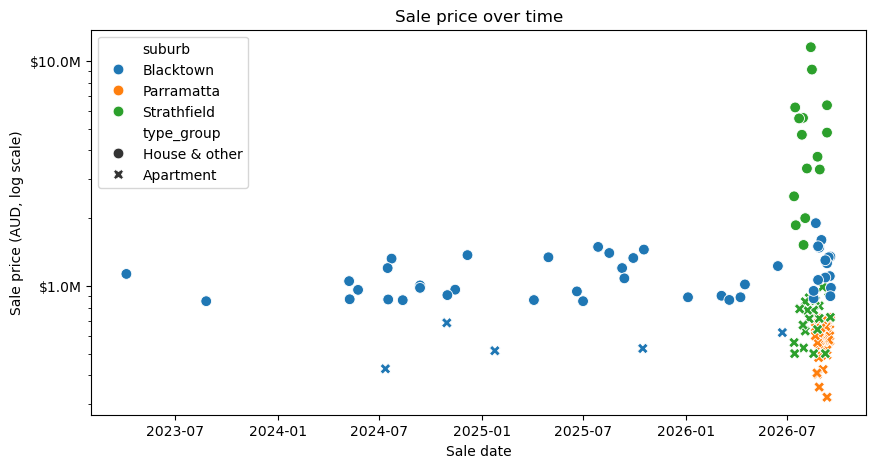

In [15]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x="sold_date", y="price", hue="suburb",
                style="type_group", hue_order=suburbs, s=60)
plt.yscale("log")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"${y/1e6:.1f}M"))
plt.xlabel("Sale date")
plt.ylabel("Sale price (AUD, log scale)")
plt.title("Sale price over time")
plt.show()

In [16]:
blacktown_houses = df[(df["suburb"] == "Blacktown") & (df["type_group"] == "House & other")]
blacktown_houses.groupby(blacktown_houses["sold_date"].dt.year)["price"].agg(["count", "median"])

,count,median
sold_date,,
2023,2,"992,500.00"
2024,12,"971,000.00"
2025,10,"1,265,000.00"
2026,21,"1,089,000.00"


## Trends over time

Parramatta and Strathfield sales are all concentrated between July and September 2026, so they cannot be used to assess price trends. Only Blacktown has sales spread from 2023 to 2026.

Blacktown's median house price does not rise steadily: AUD 992,500 (2023), AUD 971,000 (2024), AUD 1,265,000 (2025) and AUD 1,089,000 (2026). The yearly samples are small (2, 12, 10 and 21 sales), so these medians are easily shifted by which properties happened to sell.

Time is also confounded with location: most 2024 sales are in Fairwater, while the additional 2026 sales are from other parts of Blacktown. Any difference between years may therefore reflect location rather than market change. **This dataset does not provide reliable evidence of a price trend over time.**

In [17]:
df[df["flag"].notna()][["address", "price", "suburb", "property_type", "bedrooms", "flag"]]

,address,price,suburb,property_type,bedrooms,flag
41,"1404/1-3 Valentine Avenue, Parramatta NSW 2150",320000,Parramatta,Apartment/Unit,1,investment_only
56,"1403/1-3 Valentine Avenue, Parramatta NSW 2150",355000,Parramatta,Apartment/Unit,1,investment_only
86,"1/168-172 Albert Road, Strathfield NSW 2135",885000,Strathfield,Apartment/Unit,2,over55


## Flagged properties

Three properties have special sale conditions:

- **1404/1-3 and 1403/1-3 Valentine Avenue, Parramatta** (`investment_only`) sold for AUD 320,000 and AUD 355,000, the two lowest prices in the dataset. Their prices reflect a restricted buyer pool rather than normal market value, and the dataset has no feature that captures this restriction. They were **removed** before modelling, so the model does not apply to investment-only properties.
- **1/168-172 Albert Road, Strathfield** (`over55`) sold for AUD 885,000, above the Strathfield apartment median (AUD 721,000). It is the most expensive of the 12 two-bedroom apartments in Strathfield (AUD 630,000 – 885,000), but it does not fall outside that range, so it was **kept**. Notably, the over-55 restriction does not appear to have lowered its price.

Unlike the Strathfield luxury houses, which are high-priced but part of the same market, the investment-only units follow a different pricing mechanism, which is why they were treated differently.

In [18]:
df_model = df[df["flag"] != "investment_only"].copy()
print(df_model.shape)
df_model["suburb"].value_counts()

(118, 12)


suburb
Blacktown      50
Strathfield    35
Parramatta     33
Name: count, dtype: int64

## Prediction: three most influential variables

My predicted ranking is: 1. property_type, 2. suburb, and 3. land_size.

### 1. property_type

I predict that property_type will have a stronger effect on sale prices than suburb. Holding the suburb constant and changing only the property type, the price changes by up to 6.5 times in Strathfield, compared with 4.4 times for houses when holding the property type constant and changing only the suburb. This pattern also holds in the other comparison: within Blacktown, changing property type results in a 2.0 times difference, compared with 1.4 times for changing suburb among apartments. Therefore, I expect property_type to be the most influential variable.

### 2. suburb

I predict that suburb will have the second strongest effect on sale prices. The effect of suburb is still substantial, but it depends on the property type: changing suburb results in a 1.4 times difference among apartments, compared with a 4.4 times difference among houses. Suburb also has more complete data than land_size: suburb is available for all 118 properties, while only 47 of the 61 non-apartment properties have a recorded land size, and there are no land_size values for the Parramatta properties. Therefore, the estimated effect of suburb is likely to be more reliable than that of land_size.

### 3. land_size

I predict that land_size will have the third strongest effect, although this is the least certain of my three predictions. One piece of evidence is that the five most expensive properties all have relatively large land sizes, ranging from 784 to 1,730 m². Another is that the suburb effect is much stronger for houses than for apartments, which suggests that land may drive much of the price difference. However, land_size is closely linked to property_type, because apartments generally do not have their own individual land size in the same way as houses, and to suburb, because the largest blocks are concentrated among Strathfield houses. Therefore, it is difficult to separate the effect of land_size from the effects of property_type and suburb. For example, 17 Carinya St in Blacktown has 1,182 m² of land but sold for AUD 1.6 million, while 13 Augusta St in Strathfield has 1,012 m² but sold for AUD 6.35 million. This suggests that land_size alone does not determine price and that the value of land also depends strongly on the suburb.

### Excluded variables

I did not include sold_date because the Trends over time analysis did not provide reliable evidence that it would explain the differences in sale prices. I also did not rank bedrooms, bathrooms, or parking because there was not enough reliable evidence from the previous analysis to conclude that they would have a stronger effect than the three selected variables.

I did not use description directly as a model variable because it is unstructured text. However, it could be used to create new features from information such as whether a property has a granny flat, has been renovated, has a pool, or is a development site. These features could potentially provide additional information about sale prices.


In [19]:
# Do apartments have a land_size value, or are they all NaN / representing the building's total land area?
display(df.groupby("type_group")["land_size"].describe())

# For houses in Strathfield: is land_size correlated with price?
sh = df[(df["suburb"] == "Strathfield") & (df["property_type"] == "House")]
sh[["land_size", "bedrooms", "price"]].corr(method="spearman")

,count,mean,std,min,25%,50%,75%,max
type_group,,,,,,,,
Apartment,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
House & other,47.00,529.92,341.28,130.00,216.50,556.00,739.80,"1,730.00"


,land_size,bedrooms,price
land_size,1.00,0.72,0.79
bedrooms,0.72,1.00,0.84
price,0.79,0.84,1.00


In [20]:
is_apartment = df_model["type_group"] == "Apartment"

# 1. Mark houses with missing land_size
df_model["land_missing"] = (~is_apartment & df_model["land_size"].isna()).astype(int)

# 2. Apartments do not have separate land -> set to 0
df_model.loc[is_apartment, "land_size"] = 0

# 3. Houses with missing values ​​-> fill with the median land_size of houses that have data
house_median = df_model.loc[~is_apartment, "land_size"].median()
df_model["land_size"] = df_model["land_size"].fillna(house_median)

print("House median land size:", house_median)
print("Remaining missing values:", df_model["land_size"].isna().sum())
print("Properties with estimated land size:", df_model["land_missing"].sum())

House median land size: 556.0
Remaining missing values: 0
Properties with estimated land size: 14


In [21]:
# Count the number of properties priced ≤ $1.4M
n = (df["price"] <= 1_400_000).sum()
print(n, f"{n / len(df):.0%}")

# View the 5 most expensive properties
df.nlargest(5, "price")[["address", "suburb", "property_type", "land_size", "price"]]

99 82%


,address,suburb,property_type,land_size,price
85,"8-10 Llandilo Avenue, Strathfield NSW 2135",Strathfield,House,"1,730.00",11500000
84,"3 Augusta Street, Strathfield NSW 2135",Strathfield,House,"1,016.00",9150000
73,"13 Augusta Street, Strathfield NSW 2135",Strathfield,House,"1,012.00",6350000
100,"88 Albyn Road, Strathfield NSW 2135",Strathfield,House,"1,018.00",6210000
95,"9 Birnam Grove, Strathfield NSW 2135",Strathfield,House,784.10,5580000


## Feature engineering: land_size

- **Apartments:** Apartments do not own a private block of land, so `0` is a true value rather than a missing value.
- **Houses:** Houses usually have land, so missing values should not be filled with `0`, as this would make the model treat them like apartments. Instead, we use the median of 556 m² for the 14 houses with missing land size and add `land_missing` so the model knows these values were estimated.
- **Limitation:** Using one median for all suburbs ignores local differences. For example, the median is 291 m² in Blacktown but 869 m² in Strathfield, so the overall median overestimates land size for Blacktown houses and underestimates it for Strathfield houses. A separate median cannot be calculated for Parramatta because there are no houses with recorded land size there. At this stage, the median is calculated using all 118 units—which may introduce slight data leakage—but in Part 3, it will be recalculated based solely on the training set.

In [22]:
desc = df_model["description"].fillna("").str.lower()

df_model["mentions_granny_flat"] = desc.str.contains("granny").astype(int)
df_model["has_pool"] = desc.str.contains("pool").astype(int)
df_model["is_fairwater"] = desc.str.contains("fairwater").astype(int)

new_features = ["mentions_granny_flat", "has_pool", "is_fairwater"]
print(df_model[new_features].sum())

for f in new_features:
    display(df_model.groupby(f)["price"].agg(["count", "median"]))

mentions_granny_flat    12
has_pool                21
is_fairwater            21
dtype: int64


,count,median
mentions_granny_flat,,
0,106,"832,500.00"
1,12,"1,315,000.00"


,count,median
has_pool,,
0,97,"865,000.00"
1,21,"880,000.00"


,count,median
is_fairwater,,
0,97,"725,000.00"
1,21,"960,000.00"


In [23]:
df_model.groupby(["type_group", "has_pool"])["price"].agg(["count", "median"])

count       median
type_group    has_pool                    
Apartment     0            46   645,000.00
              1            11   569,000.00
House & other 0            51 1,130,000.00
              1            10 5,122,500.00

In [24]:
granny = df_model[df_model["mentions_granny_flat"] == 1]

# Classified by reading all 12 descriptions individually.
# Keyword rules cannot separate these cases: one listing with an existing granny
# flat also contains the words "potential" and "STCA" in an unrelated sentence.
existing = ["13 & 13A Stableford Street", "4 & 4A Joseph Street", "38-38A Burrell Parade"]
has_existing = granny["address"].str.startswith(tuple(existing))

display(granny.assign(existing_granny_flat=has_existing)
              .groupby("existing_granny_flat")["price"].agg(["count", "median"]))

,count,median
existing_granny_flat,,
False,9,"1,225,000.00"
True,3,"1,340,000.00"


## Feature engineering: description keywords

I created three binary features from `description` using lowercase matching.

**Features kept**

- `mentions_granny_flat` (12 properties): the median price is much higher for
  this group, 832,500 against 1,315,000. However, reading the
  descriptions shows only 3 properties actually have a granny flat, while 9 only
  mention the potential to build one ("granny flat potential (STCA)"). All 12 are
  Blacktown houses, so this feature may partly be measuring "a detached house in
  Blacktown with a large block" rather than the value of a granny flat itself.
  I renamed it from `has_granny_flat` because the original name claimed more than
  the data supports.
- `has_pool` (21 properties): overall the medians are almost identical
  (865,000 and 880,000), but splitting by property type reverses the direction:
  645,000 drops to 569,000 for apartments and 1,130,000 rises to 5,122,500
  for houses. This is because the two property types move in opposite
  directions, and pooling them together cancels the two effects out — a Simpson's
  paradox. The overall figure hides the split rather than summarising it.
- `is_fairwater` (21 properties): the median rises from 725,000 to 960,000.
  Fairwater blocks have a median land size
  of 195 m² compared with 591 m² for other Blacktown houses, so this feature
  identifies a distinct sub-market inside Blacktown — newer houses on small
  blocks — rather than duplicating the `suburb` column.

**Keywords rejected**

- "renovated" (7 properties): too few matches to support a stable median
  comparison. The word "renovate" is also ambiguous
  because it appears in listings describing a property that still *needs* work
  ("First Time to Market in 62 Years Renovate or Rebuild"), so the same keyword
  captures both renovated and unrenovated homes.
- "development": the phrase "development site" appears zero times, so the
  feature would be constant and carry no information.
- "luxury": the word reflects how the agent chose to write the listing rather
  than a physical attribute of the property. For apartments the medians are
  620,000 and 630,000, so the difference is negligible and the feature adds
  nothing over the variables already in the model.

**Limitations**

- Small samples. The 5,122,500 median for houses with a pool rests on only
  10 properties, so it could be driven by a few unusually expensive homes. The
  granny-flat group has 12 properties, and only 3 of those are genuine.
- Confounding. Properties with a pool or a granny flat tend to be larger and in
  more expensive areas, so these medians may reflect land size and location
  rather than the feature itself. A fair comparison would hold `type_group`,
  bedrooms and land size constant.
- 2 properties have no description. `fillna("")` assigns them 0 on all three
  features, which means "keyword not found" rather than "the property definitely
  does not have this". Missing data and a genuine absence are currently treated
  as the same thing.

# Part 3: Model Development and Evaluation

In [25]:
feature_cols = ["suburb", "type_group", "bedrooms", "bathrooms", "parking",
                "land_size", "land_missing", "mentions_granny_flat",
                "has_pool", "is_fairwater"]

X = pd.get_dummies(df_model[feature_cols], columns=["suburb", "type_group"],
                   drop_first=True, dtype=int)
y = np.log(df_model["price"])

print("X shape:", X.shape)
print("Features:", list(X.columns))
print("Missing values in X:", X.isna().sum().sum())
X.head()

X shape: (118, 11)
Features: ['bedrooms', 'bathrooms', 'parking', 'land_size', 'land_missing', 'mentions_granny_flat', 'has_pool', 'is_fairwater', 'suburb_Parramatta', 'suburb_Strathfield', 'type_group_House & other']
Missing values in X: 0


,bedrooms,bathrooms,parking,land_size,land_missing,mentions_granny_flat,has_pool,is_fairwater,suburb_Parramatta,suburb_Strathfield,type_group_House & other
0,3,1,2,834.70,0,1,0,0,0,0,1
1,3,1,2,582.00,0,0,0,0,0,0,1
2,2,2,1,192.00,0,0,0,1,0,0,1
3,2,2,1,155.00,0,0,0,1,0,0,1
4,2,1,1,164.50,0,0,0,1,0,0,1


## Model selection and prediction

I selected three models from three different families.

**1. Linear Regression (linear).** Linear Regression predicts price using a weighted combination of the features. It is easy to interpret, but it does not automatically capture interactions between variables.

**2. Random Forest (tree ensemble).** Random Forest splits the data into branches and can learn different price patterns for different combinations of suburb and property type. Its main strength is that it can capture nonlinear relationships and interactions.

**3. K-Nearest Neighbours (distance-based).** KNN predicts a property’s price based on the most similar properties. This is similar to how an agent might use comparable sales, but the features need to be standardised because KNN is sensitive to distance.

**Prediction.** I expect Random Forest to perform best.

The main reason is that Part 2 showed an interaction between suburb and property type: Strathfield is 1.4× more expensive than Blacktown for apartments, but 4.4× more expensive for houses. A tree-based model can split the data by suburb and then by property type, while a linear model can only use fixed coefficients and assumes the effect of suburb is the same for all property types.

A second reason is that the 11 features include both numerical and 0/1 variables, and they are on very different scales. Random Forest does not need standardisation, while KNN measures distances and can be affected by features with larger numerical scales.

I expect Linear Regression to be the weakest, because it assumes a straight-line relationship between features and log(price). The examples of 17 Carinya St and 13 Augusta St also suggest that the relationship between land_size and price is not simply linear: the Blacktown property has more land but a much lower sale price than the Strathfield property with slightly less land.


In [26]:
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "KNN (k=5)": Pipeline([("scaler", StandardScaler()),
                           ("knn", KNeighborsRegressor(n_neighbors=5))]),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"MAE": "neg_mean_absolute_error",
           "RMSE": "neg_root_mean_squared_error",
           "R2": "r2"}

rows = []
for name, model in models.items():
    r = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=True)
    pred_log = cross_val_predict(model, X, y, cv=cv)
    mae_aud = np.abs(np.exp(pred_log) - df_model["price"].values).mean()
    rows.append({"Model": name,
                 "MAE log": -r["test_MAE"].mean(),
                 "RMSE log": -r["test_RMSE"].mean(),
                 "R2 test": r["test_R2"].mean(),
                 "R2 train": r["train_R2"].mean(),
                 "MAE AUD": mae_aud})

results = pd.DataFrame(rows).set_index("Model")
results.round(3)

,MAE log,RMSE log,R2 test,R2 train,MAE AUD
Model,,,,,
Linear Regression,0.16,0.20,0.89,0.94,"304,145.81"
Random Forest,0.15,0.21,0.86,0.98,"305,993.43"
KNN (k=5),0.17,0.25,0.84,0.92,"323,913.16"


In [27]:
print("Per-fold MAE (log):")
for name, model in models.items():
    r = cross_validate(model, X, y, cv=cv, scoring="neg_mean_absolute_error")
    print(f"  {name:20s} {np.round(-r['test_score'], 3)}  sd={r['test_score'].std():.3f}")

print("\nMean MAE (log) across 10 different random splits:")
for name, model in models.items():
    means = [-cross_validate(model, X, y, cv=KFold(5, shuffle=True, random_state=s),
                             scoring="neg_mean_absolute_error")["test_score"].mean()
             for s in range(10)]
    print(f"  {name:20s} mean={np.mean(means):.3f}  min={min(means):.3f}  max={max(means):.3f}")

Per-fold MAE (log):
  Linear Regression    [0.135 0.163 0.201 0.135 0.147]  sd=0.025
  Random Forest        [0.271 0.12  0.114 0.119 0.124]  sd=0.061
  KNN (k=5)            [0.186 0.167 0.161 0.16  0.18 ]  sd=0.010

Mean MAE (log) across 10 different random splits:
  Linear Regression    mean=0.156  min=0.150  max=0.161
  Random Forest        mean=0.139  min=0.131  max=0.145
  KNN (k=5)            mean=0.166  min=0.159  max=0.178


In [28]:
expensive = df_model["price"] > 2_400_000

for name, model in models.items():
    pred = np.exp(cross_val_predict(model, X, y, cv=cv))
    ape = np.abs(pred - df_model["price"].values) / df_model["price"].values
    print(f"{name:20s} median APE={np.median(ape)*100:5.1f}%  worst={ape.max()*100:4.0f}%"
          f"  mean prediction for >2.4M = {pred[expensive.values].mean():,.0f}")

print(f"\nActual mean price for the {expensive.sum()} properties above 2.4M:"
      f" {df_model.loc[expensive, 'price'].mean():,.0f}")

Linear Regression    median APE= 12.7%  worst=  83%  mean prediction for >2.4M = 5,136,996
Random Forest        median APE= 10.5%  worst= 168%  mean prediction for >2.4M = 4,059,823
KNN (k=5)            median APE= 13.4%  worst= 109%  mean prediction for >2.4M = 3,865,435

Actual mean price for the 12 properties above 2.4M: 5,558,333


In [29]:
train_idx, test_idx = list(cv.split(X))[0]

rf_fold1 = RandomForestRegressor(n_estimators=300, random_state=42).fit(X.iloc[train_idx], y.iloc[train_idx])
lr_fold1 = LinearRegression().fit(X.iloc[train_idx], y.iloc[train_idx])

fold1 = df_model.iloc[test_idx][["address", "suburb", "land_size", "price"]].copy()
fold1["rf_pred"] = np.exp(rf_fold1.predict(X.iloc[test_idx]))
fold1["lr_pred"] = np.exp(lr_fold1.predict(X.iloc[test_idx]))
fold1["rf_error_log"] = np.abs(rf_fold1.predict(X.iloc[test_idx]) - y.iloc[test_idx])

fold1.sort_values("rf_error_log", ascending=False).head(5)

,address,suburb,land_size,price,rf_pred,lr_pred,rf_error_log
0,"28 Duckmallois Avenue, Blacktown NSW 2148",Blacktown,834.70,1225000,"3,285,420.93","1,330,195.46",0.99
99,"9 Hedges Avenue, Strathfield NSW 2135",Strathfield,556.00,5550000,"2,069,589.69","3,038,154.08",0.99
113,"17 Carinya Street, Blacktown NSW 2148",Blacktown,"1,182.40",1600000,"3,846,805.83","2,072,607.92",0.88
10,"52 Burke Street, Blacktown NSW 2148",Blacktown,751.00,1200000,"2,772,195.48","1,226,858.40",0.84
97,"8 Marion Street, Strathfield NSW 2135",Strathfield,695.60,4695000,"2,642,349.86","4,563,518.44",0.57


## Model evaluation results

**1. Results**

| Model | Log-MAE (5-fold) | RMSE (log) | Median APE | Worst APE |
|---|---|---|---|---|
| Linear Regression | 0.156 | 0.204 | 12.7% | 83% |
| Random Forest | 0.139 | 0.210 | 10.5% | 168% |
| KNN (k=5) | 0.166 | 0.251 | 13.4% | 109% |

MAE and RMSE rank the models in opposite orders: Random Forest wins on MAE but
Linear Regression wins on RMSE. This is not a contradiction — RMSE squares the
errors, so it is dominated by a small number of very large misses, while MAE
weights every property equally. Random Forest is therefore more accurate on a
typical property but produces worse outliers, which its 168% worst-case APE
confirms against 83% for Linear Regression. The two metrics answer different
questions: MAE asks "how wrong is a typical valuation?", RMSE asks "how badly can
this model fail?". Which one matters depends on whether the business cares about
average accuracy or about avoiding disasters.

**2. Overfitting**

Random Forest scores R² = 0.98 on training data but 0.86 on test data — a gap of
0.12. Linear Regression scores 0.94 and 0.89, a gap of 0.05. The forest is
memorising the training set: with 118 properties and unrestricted depth, individual
trees can isolate single houses. Linear Regression cannot do this because it only
has one coefficient per feature.

Notably, although Random Forest is the better model on MAE, its test R² (0.86) is
*lower* than Linear Regression's (0.89). Combined with the large train–test gap,
this suggests RF's advantage depends heavily on this particular sample of 118
properties and may not transfer to new data.

**3. Stability**

Across 10 different random splits, Random Forest ranges from 0.131 to 0.145 and
Linear Regression from 0.150 to 0.161. The two ranges do not overlap, so the gap
between them is not an artefact of one lucky split — RF is genuinely better on
typical properties.

Within a single 5-fold split, however, RF is far less consistent: its folds are
[0.271, 0.119, 0.114, 0.119, 0.123], sd = 0.061, against sd = 0.025 for Linear
Regression and sd = 0.010 for KNN. Fold 1 is more than twice as bad as any other
fold. RF is stable *on average* but volatile on *which properties* it gets wrong.

**4. Comparison with my predictions**

I expected Random Forest to perform best, which the MAE results confirmed. What I
did not anticipate was the direction of RF's largest errors: I assumed it would
under-predict expensive homes, but its worst fold was caused by over-predicting
cheap ones (see 5).

**5. Diagnosing the weak fold**

My first explanation for fold 1 was that it contained the luxury properties. The
data rejects this:

| Fold | Properties > 2.4M in test | RF MAE |
|---|---|---|
| 1 | 2 (fewest) | 0.271 (worst) |
| 3 | 2 (includes the 11.5M property) | 0.114 (best) |
| 5 | 4 (most) | 0.123 (good) |

Fold 1 has the fewest expensive properties and the worst score; fold 3 contains the
single most expensive property and the best score. The luxury hypothesis is wrong.

The actual cause is the opposite error — RF over-predicting cheap houses:

| Property | Actual | RF prediction |
|---|---|---|
| 28 Duckmallois | 1,225,000 | 3,285,421 |
| 17 Carinya | 1,600,000 | 3,846,806 |
| 52 Burke | 1,200,000 | 2,772,195 |

All three are Blacktown houses on large blocks. Random Forest splits aggressively
on `land_size`, and in the training data most large-block properties are in
Strathfield, so the model applies Strathfield prices to Blacktown land. The tree
learned "large block → expensive" without learning that this rule is
suburb-specific. This is a feature-interaction failure, not a luxury-tail failure.

**6. Recommendation**

- **Mass valuation across all three suburbs: Random Forest.** Median APE of 10.5%
  against 12.7%, and the non-overlapping ranges in section 3 show the advantage is
  reliable. Most properties are ordinary, and this is where RF is strongest.
- **Properties above 2.4M:  Linear Regression performs better across most of this segment: the median per-property error is −17.9%, compared with −26.1% for Random Forest. Its advantage disappears at the very top of the market, however. For 8–10 Llandilo Avenue (which sold for AUD 11.5 million), Linear Regression predicts AUD 19,225,536, an overshoot of AUD 7.7 million, while Random Forest predicts AUD 7,686,669, an error of AUD 3.8 million — roughly half the size. This reflects a structural difference between the models: Random Forest is bounded by the most expensive properties in its training data, which limits how far its predictions can extend, while Linear Regression is unbounded. That flexibility helps Linear Regression in the AUD 3–6 million range but leads to a substantial overshoot at the extreme. With only 12 properties above AUD 2.4 million, including just one above AUD 9 million, neither model should be relied on alone at the top of the market; human valuation remains important for these exceptional properties.

  Caveat: this conclusion rests on 12 properties, which is too few to be confident.
  The comparison also uses mean prediction, which measures systematic bias rather
  than per-property accuracy — over- and under-predictions can cancel out. Both
  should be checked on more data before the model is deployed for this segment.

 

# Part 4: Investigating Prediction Failures

In [30]:
rf_log_pred = cross_val_predict(RandomForestRegressor(n_estimators=300, random_state=42), X, y, cv=cv)
lr_log_pred = cross_val_predict(LinearRegression(), X, y, cv=cv)

errors = df_model[["address", "suburb", "type_group", "bedrooms", "bathrooms",
                   "land_size", "land_missing", "price"]].copy()
errors["rf_pred"] = np.exp(rf_log_pred)
errors["lr_pred"] = np.exp(lr_log_pred)
errors["rf_error_log"] = np.abs(rf_log_pred - y)
errors["rf_pct"] = (errors["rf_pred"] - errors["price"]) / errors["price"] * 100
errors["lr_pct"] = (errors["lr_pred"] - errors["price"]) / errors["price"] * 100

worst5 = errors.nlargest(5, "rf_error_log")
worst5[["address", "bedrooms", "land_size", "land_missing", "price",
        "rf_pred", "rf_pct", "lr_pred", "lr_pct"]]

,address,bedrooms,land_size,land_missing,price,rf_pred,rf_pct,lr_pred,lr_pct
0,"28 Duckmallois Avenue, Blacktown NSW 2148",3,834.70,0,1225000,"3,285,420.93",168.20,"1,330,195.46",8.59
99,"9 Hedges Avenue, Strathfield NSW 2135",5,556.00,1,5550000,"2,069,589.69",-62.71,"3,038,154.08",-45.26
113,"17 Carinya Street, Blacktown NSW 2148",3,"1,182.40",0,1600000,"3,846,805.83",140.43,"2,072,607.92",29.54
10,"52 Burke Street, Blacktown NSW 2148",3,751.00,0,1200000,"2,772,195.48",131.02,"1,226,858.40",2.24
72,"85 Redmyre Road, Strathfield NSW 2135",3,752.50,0,4800000,"2,675,639.11",-44.26,"2,800,451.01",-41.66


In [31]:
for _, row in worst5.iterrows():
    print("=" * 80)
    print(f"{row['address']}  |  actual {row['price']:,}  RF {row['rf_pred']:,.0f} ({row['rf_pct']:+.0f}%)")
    print(str(df_model.loc[row.name, "description"])[:500])

28 Duckmallois Avenue, Blacktown NSW 2148  |  actual 1,225,000  RF 3,285,421 (+168%)
SOUTH BLACKTOWN OPPORTUNITY ON 834.7SQM LAND, LOCATION & ENDLESS POTENTIAL!
Perfectly positioned in one of Blacktown's most tightly held and highly sought-after Southside pockets, 28 Duckmallois Avenue presents an outstanding opportunity to secure a rare 834.7sqm parcel of land packed with future potential.
Whether you're a first home buyer looking to break into the market, a renovator chasing your next project, an investor seeking future upside, or a developer exploring possibilities (STCA), th
9 Hedges Avenue, Strathfield NSW 2135  |  actual 5,550,000  RF 2,069,590 (-63%)
Commanding a prestigious position in one of Strathfield's most tightly held enclaves, this grand double brick residence delivers a refined fusion of timeless French Provincial elegance and modern family luxury. Set on a level parcel with a serene golf course backdrop, the home reveals expansive interiors, resort-style outdoor entert

In [32]:
big = df_model[(df_model["type_group"] == "House & other") &
               (df_model["land_size"] > 750) & (df_model["land_missing"] == 0)]
big.groupby("suburb")["price"].agg(["count", "median"])

,count,median
suburb,,
Blacktown,3,"1,225,000.00"
Strathfield,8,"5,895,000.00"


In [33]:
print(big[big["suburb"] == "Blacktown"][["address", "land_size", "price"]])

for i, (tr, te) in enumerate(cv.split(X, y), 1):
    test_ids = df_model.index[te]
    print(f"Fold {i}: large blocks in test =",
          big.loc[big.index.intersection(test_ids), "address"].tolist())

                                       address  land_size    price
0    28 Duckmallois Avenue, Blacktown NSW 2148     834.70  1225000
10         52 Burke Street, Blacktown NSW 2148     751.00  1200000
113      17 Carinya Street, Blacktown NSW 2148   1,182.40  1600000
Fold 1: large blocks in test = ['28 Duckmallois Avenue, Blacktown NSW 2148', '52 Burke Street, Blacktown NSW 2148', '17 Carinya Street, Blacktown NSW 2148']
Fold 2: large blocks in test = ['85 Redmyre Road, Strathfield NSW 2135']
Fold 3: large blocks in test = ['18 Coventry Road, Strathfield NSW 2135', '8-10 Llandilo Avenue, Strathfield NSW 2135']
Fold 4: large blocks in test = ['9 Birnam Grove, Strathfield NSW 2135', '88 Albyn Road, Strathfield NSW 2135']
Fold 5: large blocks in test = ['13 Augusta Street, Strathfield NSW 2135', '41 High Street, Strathfield NSW 2135', '3 Augusta Street, Strathfield NSW 2135']


## Five largest prediction errors

| Property | Beds | Land (m²) | Actual | RF pred | RF error | LR pred | LR error |
|---|---|---|---|---|---|---|---|
| 28 Duckmallois Ave, Blacktown | 3 | 834.7 | 1,225,000 | ...

1. **28 Duckmallois Avenue, Blacktown**: actual 1,225,000, RF 3,285,421 (+168%).
   ...

1. **28 Duckmallois Avenue, Blacktown**: actual 1,225,000, RF 3,285,421 (+168%).
   A 3-bedroom house on 834.7 m². The listing sells it as "land packed with future
   potential" (renovators, investors, developers, STCA) rather than as a home.
   The model sees a large block and prices it the way large blocks are priced in
   its training data. Of the 11 houses with a recorded land size above 750 m², 8
   are in Strathfield (median AUD 5.9M) and only 3 are in Blacktown (median AUD
   1.2M), and those 3 are the three Blacktown properties in this list. All three
   fell in the same test fold, so when the model was trained for that fold it had
   seen 8 large-block Strathfield houses and no large-block Blacktown houses at
   all. Together they account for most of fold 1's poor score of 0.271. Linear
   Regression predicts 1,330,195 (+9%).

2. **9 Hedges Avenue, Strathfield**: actual 5,550,000, RF 2,069,590 (−63%).
   Two causes. First, `land_size` was missing (`land_missing = 1`) and imputed
   as 556 m², while my notes from the Domain listing record roughly 731 m². The
   model therefore saw a block about 175 m² smaller than the real one. Second,
   nothing in the features captures what the listing emphasises: a golf-course
   backdrop, French Provincial design and a multi-generational layout. Linear
   Regression also fails (−45%).

3. **17 Carinya Street, Blacktown**: actual 1,600,000, RF 3,846,806 (+140%).
   A 1,182 m² block marketed explicitly to "developers, builders, land bankers and
   institutional investors". The model has no feature for zoning or development
   potential, and, as with Duckmallois, its large-block training examples in that
   fold were all Strathfield houses. Linear Regression: +30%.

4. **52 Burke Street, Blacktown**: actual 1,200,000, RF 2,772,195 (+131%).
   The listing opens with "Knock down and rebuild" and describes the house as "all
   original". The price reflects the land minus the cost of replacing the house,
   but the model has no feature for condition, so it values a tear-down like a
   liveable home. Linear Regression: +2%.

5. **85 Redmyre Road, Strathfield**: actual 4,800,000, RF 2,675,639 (−44%).
   Only 3 bedrooms on 752.5 m², which looks ordinary on paper. The value comes from
   a prestige street, gated entry and period features, none of which exist in the
   data. Linear Regression also fails (−42%).

**Pattern.** The errors split cleanly into two groups going in opposite
directions:

| Group | Properties | RF error | LR error |
|---|---|---|---|
| Over-predicted | 3 Blacktown land sales | +168%, +140%, +131% | +9%, +30%, +2% |
| Under-predicted | 2 Strathfield prestige homes | −63%, −44% | −45%, −42% |

The clearest illustration is 85 Redmyre Road and 52 Burke Street. They share the
same bedroom count and almost identical land size (752.5 m² vs 751 m²), yet one
sold for 4,800,000 and the other for 1,200,000. Random Forest predicts 2,675,639
and 2,772,195, almost the same figure for both, and even ranks the cheaper
property slightly higher. Given near-identical inputs, it returns a near-identical
answer between the two true prices. `land_size` alone cannot separate them; the
price of land depends on the suburb, and the model is not using suburb strongly
enough to tell these two apart.

The two groups also fail for different reasons. On the three Blacktown
properties, Linear Regression is close to correct, so those errors come from how
Random Forest splits on `land_size` combined with a training fold that contained
no comparable Blacktown examples. On the two Strathfield properties, *both*
models fail by a similar margin, so those errors come from information that is
missing from the dataset, not from the choice of model.

**Missing information.** The largest errors point to variables the dataset does
not contain: internal floor area, the age and condition of the house, zoning and
development potential, quality of finishes, and position within the suburb
(street prestige, outlook, proximity to amenities). The descriptions often state
these things in words, but the structured features do not capture them.

**When to treat predictions cautiously.**
- The property is marketed as land or as a development / knock-down opportunity,
  rather than as a home.
- `land_missing = 1`, because the imputed value may be far from the real one.
- The land size is large for its suburb, since Random Forest may apply another
  suburb's land prices.
- The predicted price is far outside the typical range for that suburb and
  property type (e.g. a Blacktown house predicted above 2.5M).
- Random Forest and Linear Regression disagree sharply. On the three Blacktown
  failures the gap between the two models was over 100 percentage points, which
  could serve as an automatic warning flag.

**Which property types are inherently harder.** Two types are hard for different
reasons. *Development sites in cheaper suburbs* are hard for tree-based models
specifically, because their value is driven by land in a way the model confuses
with prestige-suburb pricing, especially when the training data holds few
comparable examples. A simpler model already handles them better. *Prestige
homes* are hard for every model tested, because their value rests on qualities
(design, street, outlook) that no feature in this dataset records.

The first problem could be reduced in two ways, both suggested by this error
analysis rather than planned in advance. One is a suburb × land-size interaction,
so that an extra square metre is priced differently in each suburb. The other
is a description-based feature for development or knock-down listings: three of
the five largest errors are properties marketed as land rather than as homes,
using phrases such as "knock down and rebuild", "developers" and "(STCA)".
Earlier, "development site" matched zero listings, so the keyword list would need
to be built from the phrasing these listings actually use. "STCA" would also need
care, since it appears in granny-flat listings too. The second problem can only
be reduced with better data.

# Part 5: Final Deployment and Reflection

In [34]:
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

rf_final = RandomForestRegressor(n_estimators=300, random_state=42).fit(X, y)
lr_final = LinearRegression().fit(X, y)

bundle = {"rf": rf_final, "lr": lr_final, "columns": list(X.columns),
          "house_median_land": float(df_model.loc[~is_apartment, "land_size"].median())}
joblib.dump(bundle, "housing_models.joblib")

print("Saved housing_models.joblib")
print("Feature order:", bundle["columns"])

Saved housing_models.joblib
Feature order: ['bedrooms', 'bathrooms', 'parking', 'land_size', 'land_missing', 'mentions_granny_flat', 'has_pool', 'is_fairwater', 'suburb_Parramatta', 'suburb_Strathfield', 'type_group_House & other']


In [35]:
expensive_errors = errors[errors["price"] > 2_400_000].sort_values("lr_pct", ascending=False)
expensive_errors[["address", "price", "lr_pred", "lr_pct", "rf_pred", "rf_pct"]].head(3)

,address,price,lr_pred,lr_pct,rf_pred,rf_pct
85,"8-10 Llandilo Avenue, Strathfield NSW 2135",11500000,"19,225,536.42",67.18,"7,686,669.25",-33.16
80,"18 Coventry Road, Strathfield NSW 2135",3750000,"4,517,539.76",20.47,"4,208,023.05",12.21
97,"8 Marion Street, Strathfield NSW 2135",4695000,"4,563,518.44",-2.80,"2,642,349.86",-43.72


## Reflection

*All prices are in AUD. Error measures are stated with each figure, since the analysis uses several (median absolute percentage error, signed percentage error, and MAE on the log scale).*

**What surprised me most.**
I expected Random Forest to under-predict expensive properties, because it averages the prices of similar homes it has already seen and cannot predict beyond that range. Instead, its biggest error went the other way. For example, 28 Duckmallois Ave was predicted at AUD 3,285,421 against an actual price of AUD 1,225,000 (about 2.68 times too high). This taught me that a model can fail in the opposite direction from what I expect. I need to look at the individual errors, not just assume where the model will go wrong.

**Hardest and most time-consuming step.**
The hardest step was working out why fold 1 performed so badly in Part 4, and it was also the most time-consuming.
My first hypothesis was that fold 1 contained most of the luxury properties. When I checked, the data did not support this.
The real cause turned out to be that the only three large-block houses in Blacktown all fell into fold 1. When the model was tested on them, it had never seen a similar property during training.
What I learned from this is to test my explanation against the data before accepting it. In a small dataset, a few unusual properties landing in the same fold can change the result a lot.


**Challenges at each stage.**

- *Data collection:* Many listings had missing information, so I kept 32 lines of notes. Some prices were not published, some land sizes were described vaguely, and some text had font or encoding errors.
  I also found that Fairwater made up 21 of the first 35 Blacktown properties, so I collected 15 more properties from other parts of Blacktown to reduce this imbalance.
- *Preprocessing:* `land_size` was missing for 71 of 118 properties, for two different reasons. The first is that apartments do not have a private block of land, so 0 is the true value rather than a missing one. The second is that some house listings simply did not report the land size on Domain, so the value is genuinely unknown. For 14 houses, I filled in 556 m², the median land size of the 47 non-apartment properties that had a recorded value. One risk of this is that all 14 houses now look the same size, so the model cannot tell a small block from a large one among them.
- *Feature engineering:* Only 3 of the 12 listings that mentioned "granny" actually had a granny flat, and "development site" appeared 0 times. This showed me that keywords in listing descriptions are often marketing language, so I need to check them before using them as features.
- *Modelling and evaluation:* A single 5-fold split was not enough, because the result depended heavily on which properties landed in which fold. Fold 1 gave an MAE of 0.271 on the log scale, against 0.114 in another fold, which is about 31% against about 12% in multiplicative terms. I therefore repeated the cross-validation with 10 different random splits and used the average.

**Trade-off between accuracy and deployment.**
Random Forest was more accurate for typical properties (10.5% median absolute percentage error against 12.7% for Linear Regression), but it performed worse for luxury properties at the top of the price range. In the app, I handled this by showing the predictions from both models and displaying a warning when they differ by more than 25%.
The trade-off is that the user gets two numbers instead of one clear answer, which is less simple. However, it is more honest about when the model is uncertain.


**Bias and fairness.**
Not all errors cause the same harm. An error that causes a sale to go ahead at the wrong price usually cannot be undone, while an error that stops a sale from happening can be corrected, for example by lowering the asking price.
For the large Blacktown blocks, the model over-predicted by up to 168% (28 Duckmallois Ave). An owner who trusted this would list the property too high, but it would simply not sell, and the owner could lower the price later. So the cost is mainly time and a delayed sale.
For the 12 properties above AUD 2.4M, the average prediction was about 27% below the average actual price, which is about AUD 1,498,510 per property. An owner who trusted this would accept an offer that is too low, and once the contract is signed, that money cannot be recovered.
The same over-prediction also matters for buyers: a buyer who trusted the model might think an overpriced property is fair value and end up paying too much.
Although the Blacktown error is much larger in percentage terms (168% over against 27% under), the group harmed most is owners of luxury properties, because their loss is permanent once the sale is completed.

**Data limitations.**
The dataset has only 118 properties from 3 suburbs. It contains 59 apartments but only 33 houses, so the model has less information about houses.
Parramatta has no houses with land in the dataset, so the model cannot reliably predict house prices there.
I also removed 2 investment-only properties, and the properties were sold at different times, so changes in the market during that period are not captured by the model.


**If I had another month and a budget.**
My first priority would be collecting more houses with land, especially in Parramatta, because this is the biggest gap in the current data.
I would also add features such as floor area, building age and zoning, and an interaction between suburb and land size, so the model can learn that the same land size is worth different amounts in different suburbs.
The extension I would most like to build is a tool that compares the predicted price with the listed price to find properties that may be good value. However, I would need to be careful, because the model's error is still about 10.5%, so a property that looks 10% "cheap" may just be model error. Also, a property that is cheap compared with the prediction may actually be an old house that needs to be knocked down and rebuilt.
